In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv('TitanicDataset.csv')
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
#handling the missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop(columns=['Cabin'])

Missing values in the age column were filled using the median. 
Missing values in the embarked column were filled using the most frequent category.
We dropped the cabin column due to excessive missing values.

In [7]:
df.isnull().sum() #no missing 

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [8]:
df.duplicated().sum() #no duplicates

np.int64(0)

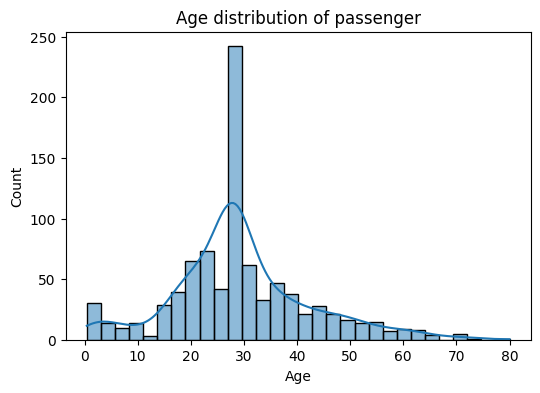

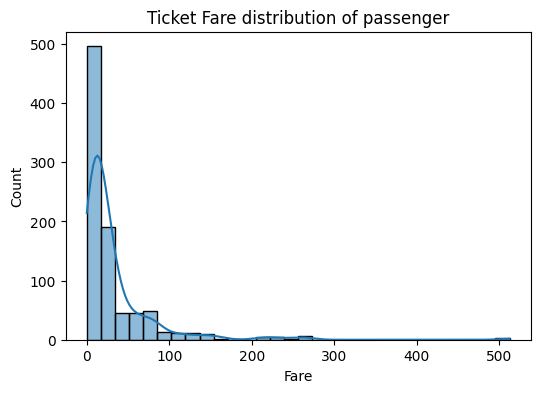

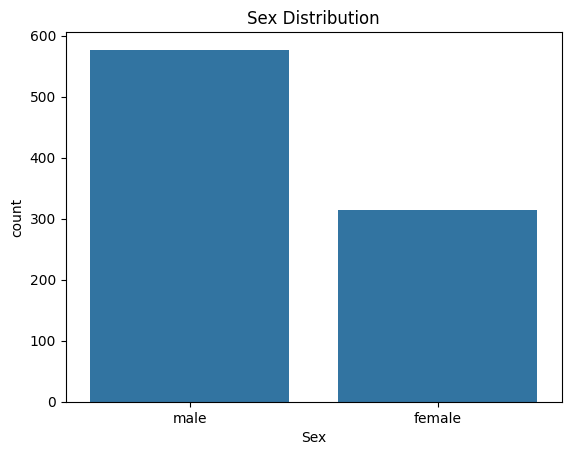

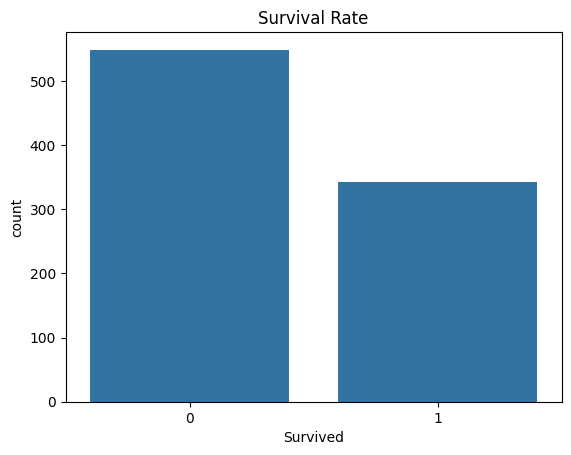

In [9]:
#Quick distribution plots
#Age Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=30,kde = True)
plt.title("Age distribution of passenger")
plt.show()

#Ticket fare distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Fare'], bins=30,kde = True)
plt.title("Ticket Fare distribution of passenger")
plt.show()

#Sex Distribution
sns.countplot(data=df, x='Sex')
plt.title('Sex Distribution')
plt.show()

#Survival Rate Distribution
sns.countplot(data=df, x='Survived')
plt.title('Survival Rate')
plt.show()

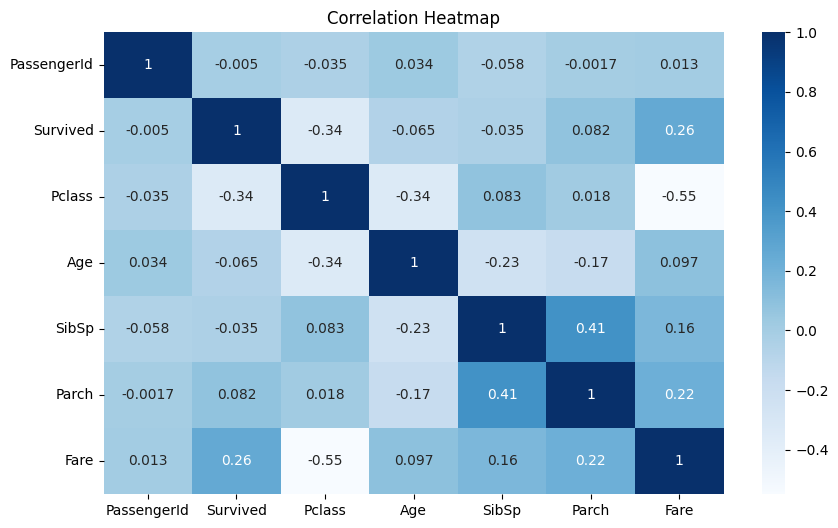

In [10]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()
#We can see from that heatmap that there is a correlation between the survival and the fare\class
#But this do not include correlations with the categorical features

In [11]:
#encoding the categorical features to include them in the correlation heatmap
df_encoded = df.copy()

#detecting categorical features
cat_cols = df_encoded.select_dtypes(include=['object']).columns.tolist()
cat_cols

#encoding
le = LabelEncoder()

for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

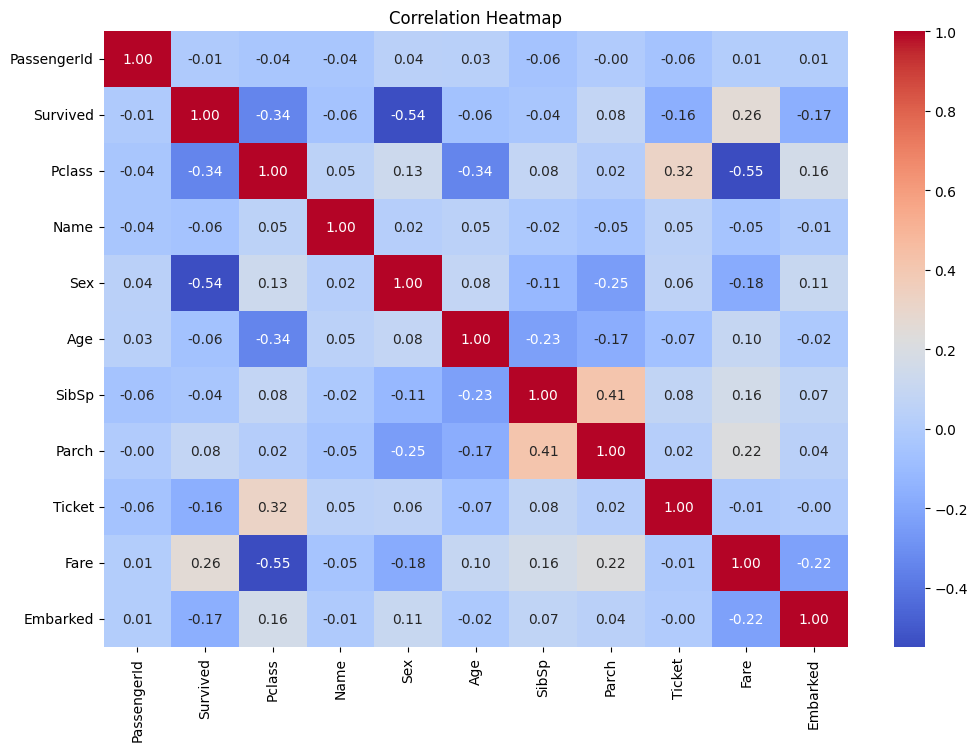

In [12]:
#plotting the heatmap that inc;udes categorical features
plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show() 
#after checking the heatmap that include the categorical features we can see that there is also a correlation between survival and sex as well

Survival Rate by Gender:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


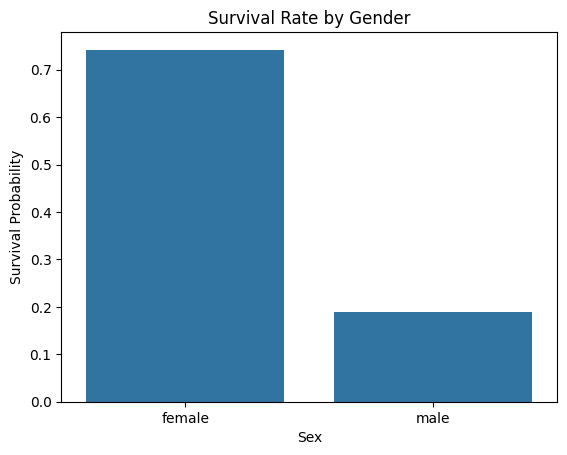


Survival Rate by Passenger Class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


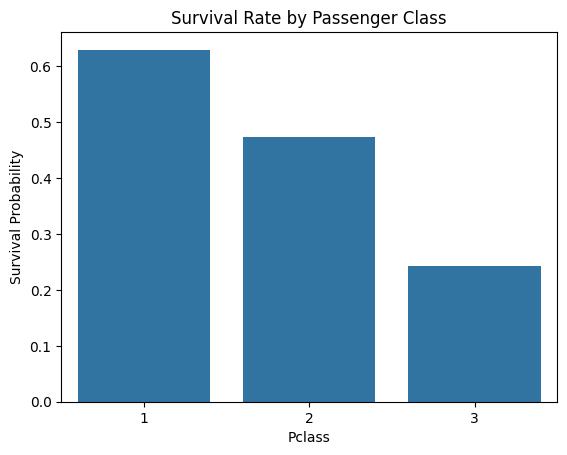

In [13]:
# Survival rate by gender
survival_by_gender = df.groupby('Sex')['Survived'].mean()
print("Survival Rate by Gender:")
print(survival_by_gender)

sns.barplot(x=survival_by_gender.index, y=survival_by_gender.values)
plt.title("Survival Rate by Gender")
plt.ylabel("Survival Probability")
plt.show()


# Survival rate by passenger class
survival_by_class = df.groupby('Pclass')['Survived'].mean()
print("\nSurvival Rate by Passenger Class:")
print(survival_by_class)

sns.barplot(x=survival_by_class.index, y=survival_by_class.values)
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Probability")
plt.show()

### Key insights
- Females had a significantly higher survival rate than males.
- passengers in the 1st class had higher survival probabilities than those in 2nd and 3rd class
- Fare and passenger class show noticable correlation with survival 
